In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm
import json
import seaborn as sns
import plot_utils

/home/ecp/software/venvs/py-3.6.6/lib/python3.6/site-packages/pandas/compat/__init__.py:117: UserWarning: Could not import the lzma module. Your installed Python is incomplete. Attempting to use lzma compression will result in a RuntimeError.
  warnings.warn(msg)


In [2]:
pocam_2 = 26
hem_2 = 51
emitter_2 = 'LMG450'
batch_2 = 2


In [3]:
pocam_1 = 11
hem_1 = 13
emitter_1 = 'LMG450'
batch_1 = 1

In [11]:
file_path_1 = f'../output/batch{batch_1:01d}/pocam_{pocam_1:03d}/hem_{hem_1:02d}/{emitter_1}/isotropy.json'
file_path_2 = f'../output/batch{batch_2:01d}/pocam_{pocam_2:03d}/hem_{hem_2:02d}/{emitter_2}/isotropy.json'

In [12]:
with open(file_path_1, "r") as f:
    data_1 = json.load(f)
    
with open(file_path_2, "r") as f:
    data_2 = json.load(f)

In [13]:
def truncate_colormap(cmap, minval=0.0, maxval=0.8, n=256):
    return LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval},{maxval})",
        cmap(np.linspace(minval, maxval, n))
    )

In [14]:
cmap_trunc = truncate_colormap(cm.Blues_r, 0, 1)

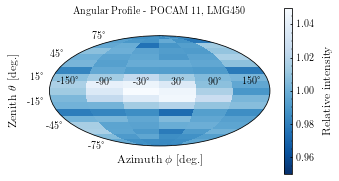

In [17]:
data = data_1
d = data["meas_data"][0]
Z = np.array(d["z_values"])

x = np.linspace(d["x_min"], d["x_max"], d["x_bins"]+1)
y = np.linspace(d["y_min"], d["y_max"], d["y_bins"]+1)

fig = plt.figure(figsize=plot_utils.set_size('wide', fraction=0.7, subplots=(1, 1)))
ax = fig.add_subplot(111, projection="mollweide")

c = ax.pcolormesh(x, y, Z, cmap = cmap_trunc, vmin = 0.95, vmax = 1.05)

ax.set_title(f'Angular Profile - POCAM {pocam_1}, {emitter_1}', y = 1.3)
ax.set_xticks(np.radians(np.arange(-150,200, 60)))
ax.set_yticks(np.radians(np.arange(-75,80, 30)))
fig.colorbar(c, ax=ax, label="Relative intensity")
ax.set_xlabel(r'Azimuth $\phi$ [deg.]')
ax.set_ylabel(r'Zenith $\theta$ [deg.]')

plt.savefig(f'plots/png/ang_prof_pocam_{pocam_1}_{emitter_1}.png')
plt.savefig(f'plots/pdf/ang_prof_pocam_{pocam_1}_{emitter_1}.pdf')

In [18]:
import healpy as hp

0.0 180.0 -180.0 180.0
The interval between parallels is 30 deg -0.00'.
The interval between meridians is 30 deg -0.00'.


Text(0, 0.5, 'Zenith $\\theta$ [deg.]')

/home/ecp/software/venvs/py-3.6.6/lib/python3.6/site-packages/healpy/projaxes.py:1155: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if matplotlib.cbook.iterable(value):
/home/ecp/software/venvs/py-3.6.6/lib/python3.6/site-packages/healpy/projaxes.py:1155: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if matplotlib.cbook.iterable(value):


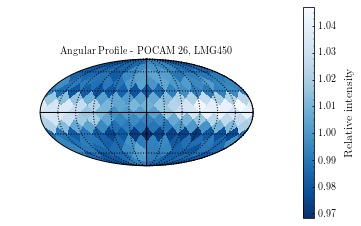

In [20]:
data = data_2
NSIDE = 2**2
NPIX = hp.nside2npix(NSIDE)

vec = hp.ang2vec(np.pi / 2, np.pi * 3 / 4)
ipix_disc = hp.query_strip(NSIDE, np.radians(0), np.radians(150))
deg = np.degrees(hp.pix2ang(nside=NSIDE, ipix=ipix_disc))

d = data["meas_data"][0]
Z = np.array(d["z_values"])

fig = plt.figure(figsize=plot_utils.set_size('wide', fraction=0.7, subplots=(1, 1)))
hp.mollview(
    Z,
    fig=fig.number,
    sub=(1, 1, 1),
    title='',
    cmap=cmap_trunc,
    cbar=False  
)

hp.graticule()

# get axis + image
ax = fig.gca()
im = ax.get_images()[0]   # this is the mappable for colorbar

# custom colorbar
cbar = fig.colorbar(im, ax=ax, orientation='vertical')
cbar.set_label("Relative intensity")

ax.set_title(f'Angular Profile - POCAM {pocam_2}, {emitter_2}', y = 1.3)
ax.set_xticks(np.radians(np.arange(-150,200, 60)))
ax.set_yticks(np.radians(np.arange(-75,80, 30)))
# fig.colorbar(c, ax=ax, label="Relative intensity")
ax.set_xlabel(r'Azimuth $\phi$ [deg.]')
ax.set_ylabel(r'Zenith $\theta$ [deg.]')

# plt.savefig(f'plots/png/ang_prof_pocam_{pocam}_{emitter}.png')
# plt.savefig(f'plots/pdf/ang_prof_pocam_{pocam}_{emitter}.pdf')

In [21]:
from matplotlib.ticker import NullLocator, FixedLocator, FuncFormatter

NSIDE = 2**2
d = data_1["meas_data"][0]
Z = np.array(d["z_values"])
x = np.linspace(d["x_min"], d["x_max"], d["x_bins"]+1)
y = np.linspace(d["y_min"], d["y_max"], d["y_bins"]+1)

d_2 = data_2["meas_data"][0]
Z_2 = np.array(d_2["z_values"])

vmin, vmax = 0.95, 1.05

# ── Convert HEALPix map to 2D lon/lat grid ─────────────────────────────────
xsize = 800  # resolution of the reprojected grid
lon = np.linspace(-np.pi, np.pi, xsize)
lat = np.linspace(-np.pi/2, np.pi/2, xsize//2)
LON, LAT = np.meshgrid(lon, lat)

# Convert lat/lon grid to HEALPix pixel indices and sample the map
theta_hp = np.pi/2 - LAT          # colatitude
phi_hp   = LON + np.pi            # [0, 2pi]
ipix     = hp.ang2pix(NSIDE, theta_hp, phi_hp)
Z_2_grid = Z_2[ipix]

In [22]:
# ── Shared tick setup ──────────────────────────────────────────────────────
x_ticks = np.radians(np.arange(-150, 180, 60))
y_ticks = np.radians(np.arange(-75, 80, 30))
y_ticks_label = np.arange(-75, 80, 30)

def setup_ax(ax):
    ax.xaxis.set_major_locator(FixedLocator(x_ticks))
    ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{round(np.degrees(x)):.0f}'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{round(np.degrees(x)):.0f}'))
    ax.set_xlabel(r'Azimuth $\phi$ [deg]')
    if ax == ax1:
        ax.set_ylabel(r'Zenith $\theta$ [deg]')
    ax.grid(True)

In [ ]:
fig = plt.figure(figsize=plot_utils.set_size('wide', fraction=1.0, subplots=(1, 2)))
# ── Panel 1: pcolormesh mollweide ──────────────────────────────────────────
ax1 = fig.add_axes([0.05, 0.1, 0.38, 0.75], projection='mollweide')
c1 = ax1.pcolormesh(x, y, Z, cmap=cmap_trunc, vmin=vmin, vmax=vmax)
setup_ax(ax1)
ax1.set_title('Batch 1', y = 1.3)

# ── Panel 2: HEALPix reprojected to pcolormesh mollweide ──────────────────
ax2 = fig.add_axes([0.48, 0.1, 0.38, 0.75], projection='mollweide')
ax2.pcolormesh(LON, LAT, Z_2_grid, cmap=cmap_trunc, vmin=vmin, vmax=vmax)
setup_ax(ax2)
ax2.set_title('Batch 2', y = 1.3)

# ── Single shared colorbar ─────────────────────────────────────────────────
cax = fig.add_axes([0.89, 0.1, 0.02, 0.75])
fig.colorbar(c1, cax=cax, label="Relative intensity")

plt.savefig(f'plots/png/ang_prof_pocam_{pocam_1}_batch1_{pocam_2}_batch2_{emitter_1}.png', bbox_inches='tight')
plt.savefig(f'plots/pdf/ang_prof_pocam_{pocam_1}_batch1_{pocam_2}_batch2_{emitter_2}.pdf', bbox_inches='tight')